# MetaMask — Gas Pattern Analysis
Analyse statistique des transactions Ethereum pour identifier les patterns de fingerprinting.

In [16]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

DB_PATH = 'gas.db'
WALLET = 'MetaMask'

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    "SELECT * FROM transactions WHERE wallet = ?",
    conn, params=(WALLET,)
)
conn.close()

print(f"Transactions chargées : {len(df):,}")
df.dtypes

Transactions chargées : 102,432


hash                     str
block                  int64
from_addr                str
wallet                   str
max_fee_gwei         float64
max_priority_gwei    float64
base_fee_gwei        float64
fee_factor           float64
fee_factor_parent    float64
gas_limit              int64
estimated_gas        float64
gas_limit_factor     float64
tx_type                int64
dtype: object

## 1. Vue d'ensemble — valeurs manquantes et statistiques de base

In [17]:
numeric_cols = ['max_fee_gwei', 'max_priority_gwei', 'base_fee_gwei',
                'fee_factor', 'fee_factor_parent', 'gas_limit', 'estimated_gas', 'gas_limit_factor']

null_pct = df[numeric_cols].isnull().mean() * 100
print("=== Valeurs manquantes (%) ===")
print(null_pct.round(2).to_string())
print()
print("=== Statistiques de base ===")
df[numeric_cols].describe().round(4)

=== Valeurs manquantes (%) ===
max_fee_gwei          2.75
max_priority_gwei     2.75
base_fee_gwei         0.00
fee_factor            2.75
fee_factor_parent     2.75
gas_limit             0.00
estimated_gas        18.30
gas_limit_factor     18.30

=== Statistiques de base ===


,max_fee_gwei,max_priority_gwei,base_fee_gwei,fee_factor,fee_factor_parent,gas_limit,estimated_gas,gas_limit_factor
count,99617.0000,99617.0000,102432.0000,99617.0000,99617.0000,1.024320e+05,8.368600e+04,83686.0000
mean,2.4332,1.0190,0.0467,31.6272,31.5006,7.477383e+05,4.413624e+05,11.2513
std,16.0182,4.4003,0.0510,341.3583,339.0534,2.409737e+06,1.834899e+06,76.6258
min,0.0207,0.0000,0.0196,0.0000,0.0000,2.100000e+04,2.100000e+04,0.1625
25%,0.0726,0.0238,0.0345,1.0206,1.0364,7.770000e+04,4.409425e+04,1.1000
50%,0.5122,0.1760,0.0395,1.3018,1.2997,1.065580e+05,8.553400e+04,1.5000
75%,2.0579,2.0000,0.0458,1.5080,1.4797,3.500000e+05,2.292395e+05,1.5000
max,900.0000,777.0000,1.0551,16583.8667,14726.8920,1.677700e+07,1.677722e+07,706.8803


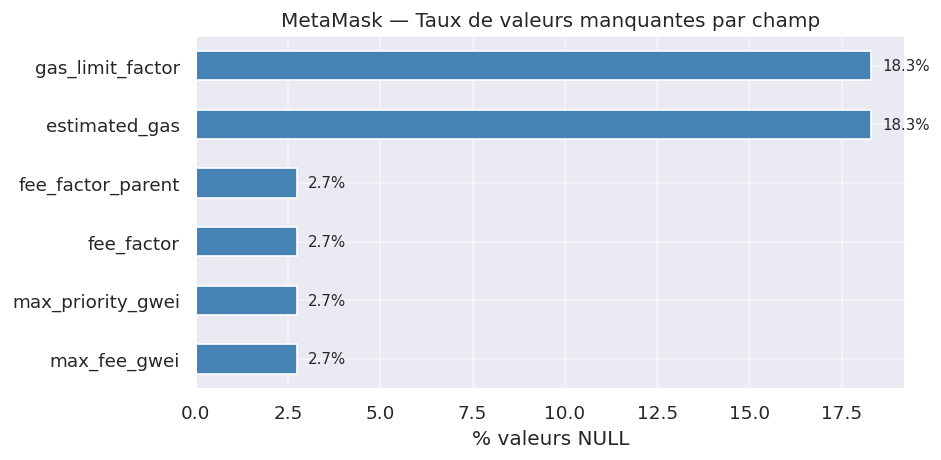

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
null_pct[null_pct > 0].sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('% valeurs NULL')
ax.set_title(f'{WALLET} — Taux de valeurs manquantes par champ')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. tx_type — répartition des types de transactions

Distribution tx_type — MetaMask
  Legacy (type 0)        :  2,776  (2.7%)
  EIP-2930 (type 1)      :     39  (0.0%)
  EIP-1559 (type 2)      : 95,179  (92.9%)
  EIP-7702 (type 4)      :  4,438  (4.3%)


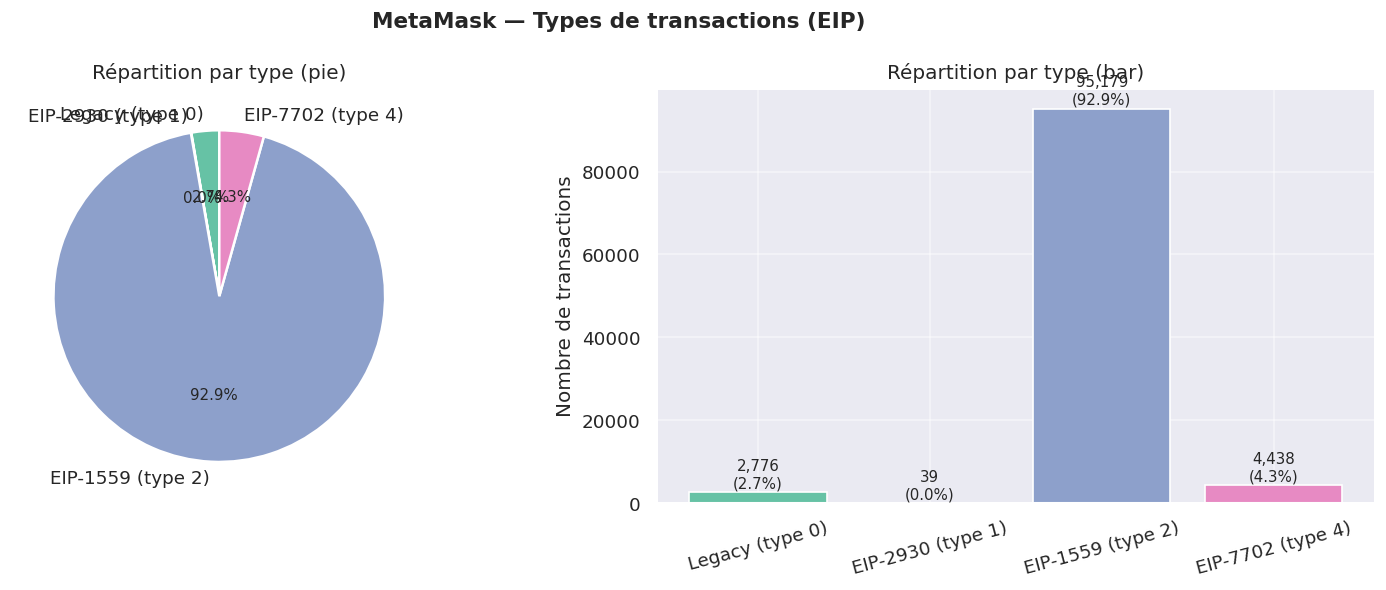


gas_limit_factor médian par tx_type :
  Legacy (type 0)        glf médian=1.003  prio médian=nan Gwei
  EIP-2930 (type 1)      glf médian=1.250  prio médian=nan Gwei
  EIP-1559 (type 2)      glf médian=1.500  prio médian=0.2335 Gwei
  EIP-7702 (type 4)      glf médian=28.254  prio médian=0.0001 Gwei


In [19]:
TX_LABELS = {0: 'Legacy (type 0)', 1: 'EIP-2930 (type 1)', 2: 'EIP-1559 (type 2)', 4: 'EIP-7702 (type 4)'}

df['tx_type_int'] = df['tx_type'].fillna(-1).astype(int)
type_counts = df['tx_type_int'].value_counts().sort_index()
type_labels = [TX_LABELS.get(t, f'type {t}') for t in type_counts.index]

print(f"Distribution tx_type — {WALLET}")
for t, n in type_counts.items():
    lbl = TX_LABELS.get(t, f'type {t}')
    print(f"  {lbl:<22} : {n:>6,}  ({n/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
palette_types = sns.color_palette('Set2', len(type_counts))
wedges, texts, autotexts = axes[0].pie(
    type_counts.values,
    labels=type_labels,
    autopct='%1.1f%%',
    colors=palette_types,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Répartition par type (pie)')

# Bar chart
bars = axes[1].bar(type_labels, type_counts.values,
                   color=palette_types, edgecolor='white')
axes[1].set_title('Répartition par type (bar)')
axes[1].set_ylabel('Nombre de transactions')
axes[1].tick_params(axis='x', rotation=15)
for bar, (t, n) in zip(bars, type_counts.items()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.003,
                 f'{n:,}\n({n/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'{WALLET} — Types de transactions (EIP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Crosstab tx_type x gas_limit_factor principal
print("\ngas_limit_factor médian par tx_type :")
for t, grp in df.groupby('tx_type_int'):
    lbl = TX_LABELS.get(t, f'type {t}')
    glf_med = grp['gas_limit_factor'].median()
    prio_med = grp['max_priority_gwei'].median()
    print(f"  {lbl:<22} glf médian={glf_med:.3f}  prio médian={prio_med:.4f} Gwei")

## 3. gas_limit_factor — formule gasLimit = estimatedGas × factor

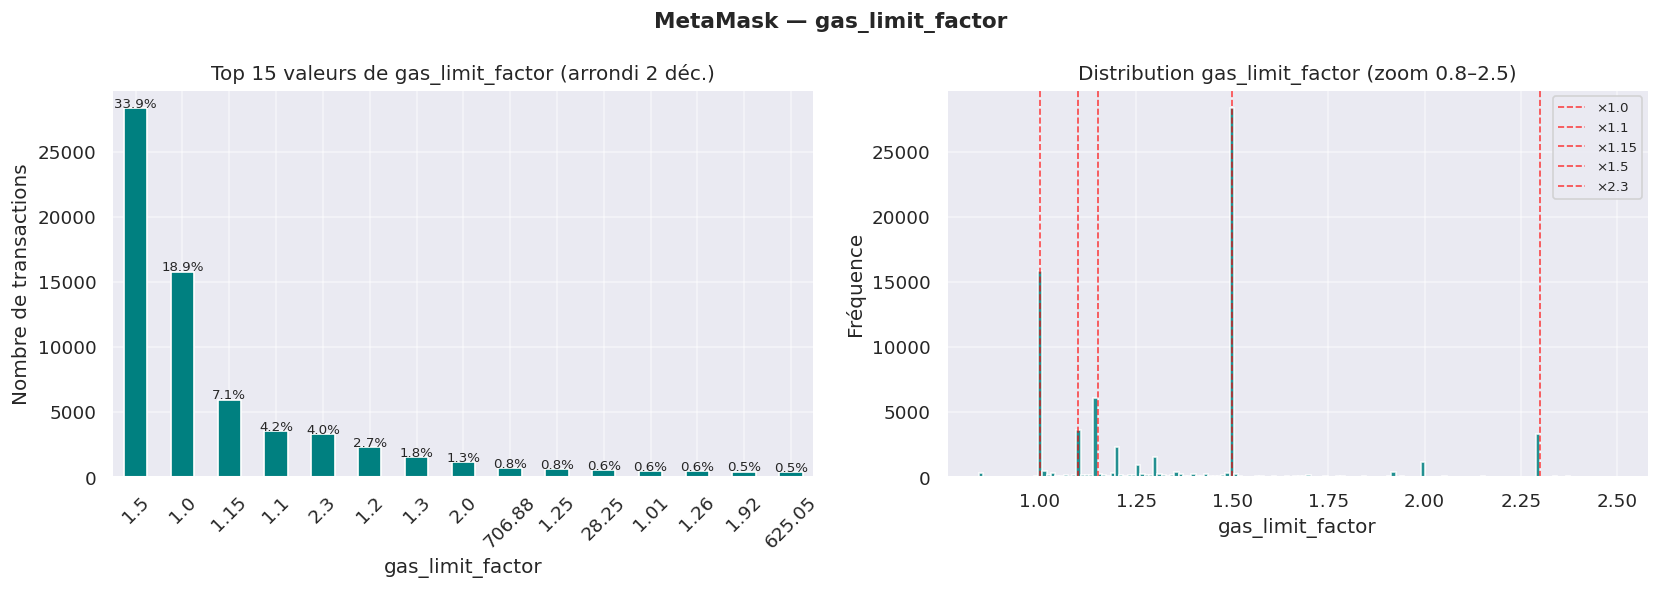


Transactions SANS estimated_gas (gas_limit_factor NULL) : 18,746 (18.3%)


In [20]:
df_glf = df[df['gas_limit_factor'].notna()].copy()
df_glf['glf_rounded'] = df_glf['gas_limit_factor'].round(2)

top_glf = df_glf['glf_rounded'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_glf.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Top 15 valeurs de gas_limit_factor (arrondi 2 déc.)')
axes[0].set_xlabel('gas_limit_factor')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    pct = bar.get_height() / len(df_glf) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{pct:.1f}%', ha='center', fontsize=8)

# Distribution continue zoom 0.8 – 2.5
zoom = df_glf[(df_glf['gas_limit_factor'] >= 0.8) & (df_glf['gas_limit_factor'] <= 2.5)]
axes[1].hist(zoom['gas_limit_factor'], bins=150, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution gas_limit_factor (zoom 0.8–2.5)')
axes[1].set_xlabel('gas_limit_factor')
axes[1].set_ylabel('Fréquence')
for v, lbl in [(1.0, '×1.0'), (1.1, '×1.1'), (1.15, '×1.15'), (1.5, '×1.5'), (2.3, '×2.3')]:
    axes[1].axvline(v, color='red', linestyle='--', linewidth=1, alpha=0.7, label=lbl)
axes[1].legend(fontsize=8)

plt.suptitle(f'{WALLET} — gas_limit_factor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTransactions SANS estimated_gas (gas_limit_factor NULL) : {df['gas_limit_factor'].isna().sum():,} ({df['gas_limit_factor'].isna().mean()*100:.1f}%)")

In [21]:
# Vérifier la précision des factors dominants
for target, label in [(1.0, '1.0'), (1.1, '1.1'), (1.15, '1.15'), (1.5, '1.5'), (2.3, '2.3')]:
    subset = df_glf[df_glf['glf_rounded'] == target].copy()
    if len(subset) == 0:
        continue
    exact = subset['gas_limit'] / subset['estimated_gas']
    print(f"gas_limit_factor ≈ {label} : {len(subset):,} txs")
    print(f"  médiane exacte : {exact.median():.8f}  |  std : {exact.std():.8f}")
    print(f"  gas_limit == estimated_gas × {label} exactement : {((exact - target).abs() < 1e-6).sum():,}/{len(subset):,}")
    print()

gas_limit_factor ≈ 1.0 : 15,789 txs
  médiane exacte : 1.00000000  |  std : 0.00088669
  gas_limit == estimated_gas × 1.0 exactement : 13,786/15,789

gas_limit_factor ≈ 1.1 : 3,534 txs
  médiane exacte : 1.09996601  |  std : 0.00074731
  gas_limit == estimated_gas × 1.1 exactement : 494/3,534

gas_limit_factor ≈ 1.15 : 5,959 txs
  médiane exacte : 1.14962247  |  std : 0.00067257
  gas_limit == estimated_gas × 1.15 exactement : 811/5,959

gas_limit_factor ≈ 1.5 : 28,342 txs
  médiane exacte : 1.50000000  |  std : 0.00024462
  gas_limit == estimated_gas × 1.5 exactement : 16,475/28,342

gas_limit_factor ≈ 2.3 : 3,325 txs
  médiane exacte : 2.29900913  |  std : 0.00017119
  gas_limit == estimated_gas × 2.3 exactement : 0/3,325



## 4. max_priority_gwei — valeurs du tip

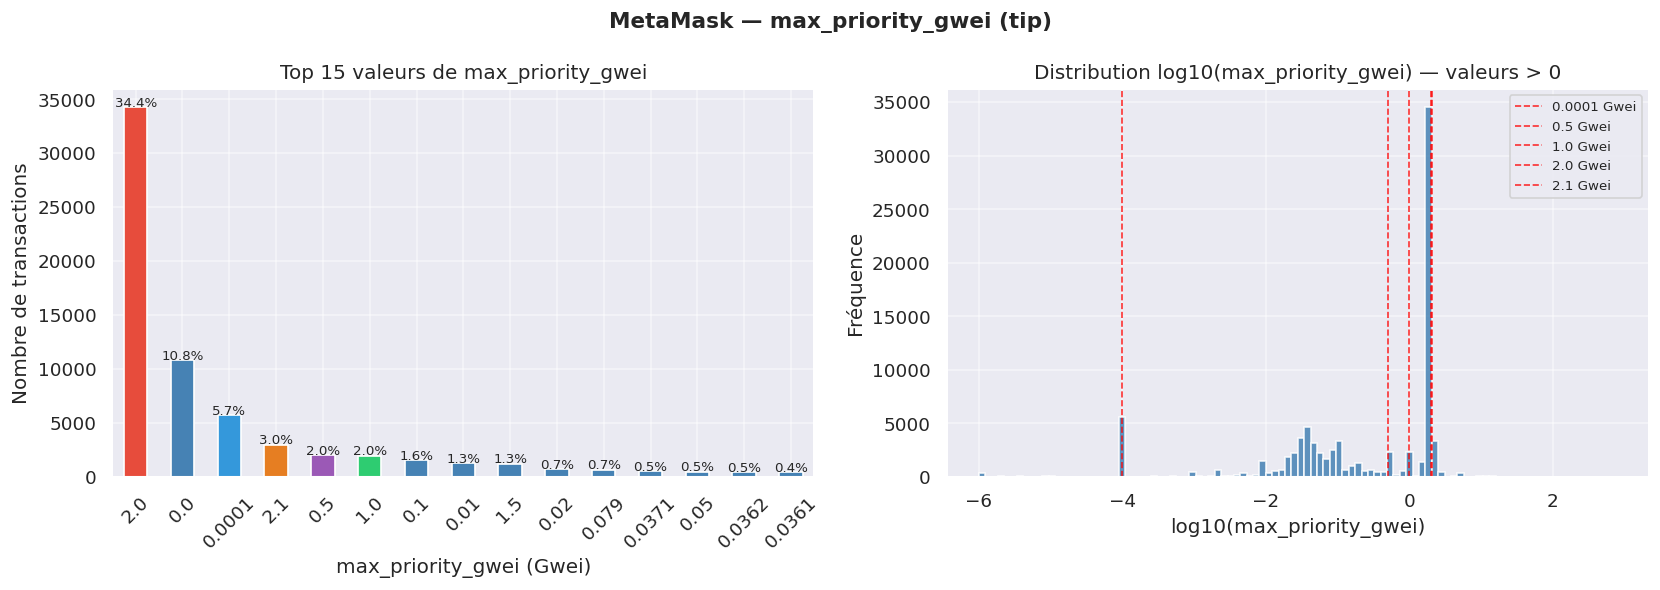

prio = 0.0    : 9,955 (10.0%)
prio = 0.0001 : 5,714 (5.7%) ← mode slow?
prio = 2.0    : 34,242 (34.4%) ← mode medium?
prio = 2.1    : 2,980 (3.0%) ← mode fast?


In [22]:
df_prio = df[df['max_priority_gwei'].notna()].copy()
df_prio['prio_rounded'] = df_prio['max_priority_gwei'].round(4)

top_prio = df_prio['prio_rounded'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colorier les valeurs spécifiques MetaMask connues
known = {2.0: '#e74c3c', 0.0001: '#3498db', 2.1: '#e67e22', 0.5: '#9b59b6', 1.0: '#2ecc71'}
colors = [known.get(v, 'steelblue') for v in top_prio.index]
top_prio.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Top 15 valeurs de max_priority_gwei')
axes[0].set_xlabel('max_priority_gwei (Gwei)')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    pct = bar.get_height() / len(df_prio) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{pct:.1f}%', ha='center', fontsize=8)

# Distribution log-scale des valeurs > 0
nonzero_prio = df_prio[df_prio['max_priority_gwei'] > 0]['max_priority_gwei']
axes[1].hist(np.log10(nonzero_prio + 1e-9), bins=100, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution log10(max_priority_gwei) — valeurs > 0')
axes[1].set_xlabel('log10(max_priority_gwei)')
axes[1].set_ylabel('Fréquence')
for v, lbl in [(0.0001, '0.0001'), (0.5, '0.5'), (1.0, '1.0'), (2.0, '2.0'), (2.1, '2.1')]:
    axes[1].axvline(np.log10(v), color='red', linestyle='--', linewidth=1, alpha=0.8, label=f'{lbl} Gwei')
axes[1].legend(fontsize=8)

plt.suptitle(f'{WALLET} — max_priority_gwei (tip)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"prio = 0.0    : {(df_prio['max_priority_gwei']==0).sum():,} ({(df_prio['max_priority_gwei']==0).mean()*100:.1f}%)")
print(f"prio = 0.0001 : {(df_prio['prio_rounded']==0.0001).sum():,} ({(df_prio['prio_rounded']==0.0001).mean()*100:.1f}%) ← mode slow?")
print(f"prio = 2.0    : {(df_prio['prio_rounded']==2.0).sum():,} ({(df_prio['prio_rounded']==2.0).mean()*100:.1f}%) ← mode medium?")
print(f"prio = 2.1    : {(df_prio['prio_rounded']==2.1).sum():,} ({(df_prio['prio_rounded']==2.1).mean()*100:.1f}%) ← mode fast?")

## 5. fee_factor — relation max_fee / base_fee

fee_factor = 0.0 : 3,008 txs (3.0%)
  max_fee_gwei moyen   : 1.771430
  base_fee_gwei moyen  : 0.047728
  → max_fee == priority? 100.0%

fee_factor ≈ 1.0 : 14,164 txs (14.2%)
  max_priority médian dans ce cas : 0.0370 Gwei



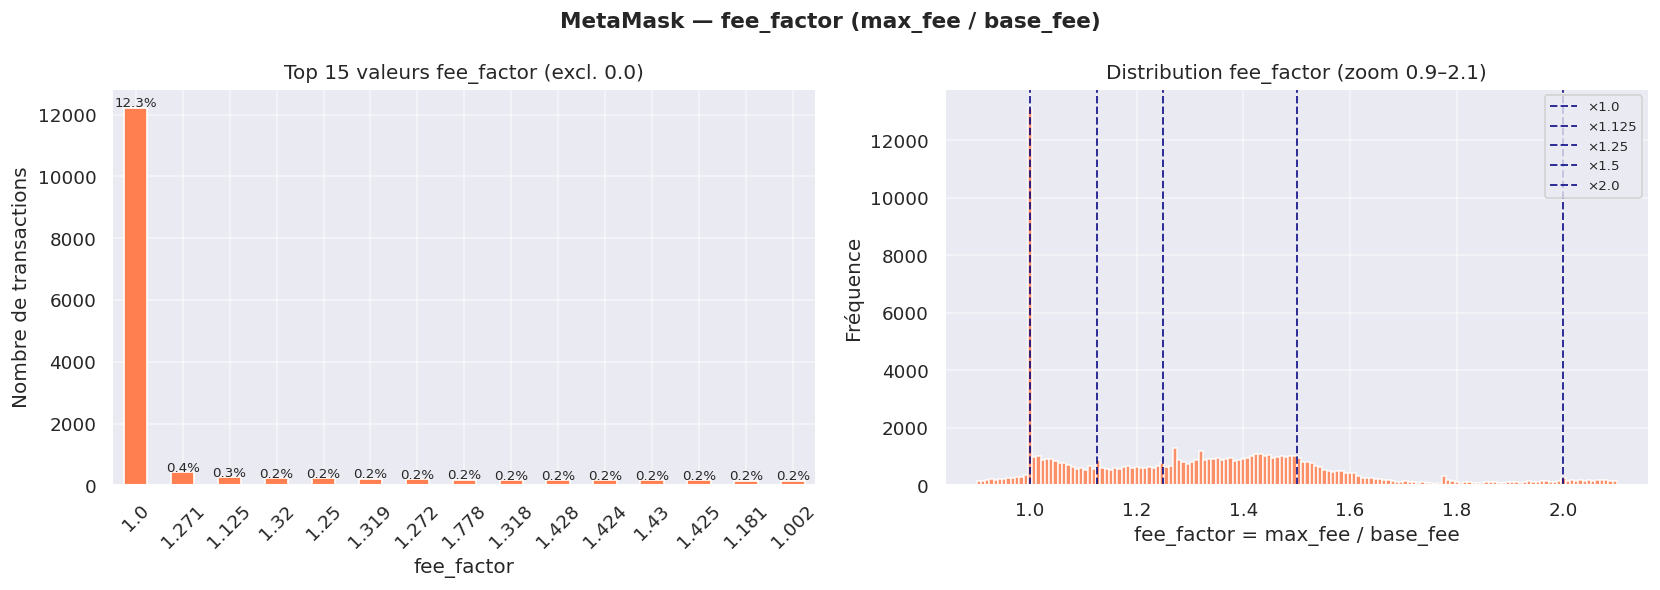

In [23]:
df_ff = df[df['fee_factor'].notna()].copy()
df_ff['ff_rounded'] = df_ff['fee_factor'].round(3)

# Cas fee_factor = 0.0
zero_ff = df_ff[df_ff['fee_factor'] == 0.0]
print(f"fee_factor = 0.0 : {len(zero_ff):,} txs ({len(zero_ff)/len(df_ff)*100:.1f}%)")
print(f"  max_fee_gwei moyen   : {zero_ff['max_fee_gwei'].mean():.6f}")
print(f"  base_fee_gwei moyen  : {zero_ff['base_fee_gwei'].mean():.6f}")
print(f"  → max_fee == priority? {(zero_ff['max_fee_gwei'].round(6) == zero_ff['max_priority_gwei'].round(6)).mean()*100:.1f}%")
print()

# Cas fee_factor = 1.0
one_ff = df_ff[(df_ff['fee_factor'] > 0.99) & (df_ff['fee_factor'] < 1.01)]
print(f"fee_factor ≈ 1.0 : {len(one_ff):,} txs ({len(one_ff)/len(df_ff)*100:.1f}%)")
print(f"  max_priority médian dans ce cas : {one_ff['max_priority_gwei'].median():.4f} Gwei")
print()

top_ff = df_ff[df_ff['fee_factor'] > 0]['ff_rounded'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_ff.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Top 15 valeurs fee_factor (excl. 0.0)')
axes[0].set_xlabel('fee_factor')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    pct = bar.get_height() / len(df_ff) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{pct:.1f}%', ha='center', fontsize=8)

# Distribution fee_factor entre 0.9 et 2.1
zoom_ff = df_ff[(df_ff['fee_factor'] > 0.9) & (df_ff['fee_factor'] <= 2.1)]
axes[1].hist(zoom_ff['fee_factor'], bins=150, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution fee_factor (zoom 0.9–2.1)')
axes[1].set_xlabel('fee_factor = max_fee / base_fee')
axes[1].set_ylabel('Fréquence')
for v, lbl in [(1.0, '×1.0'), (1.125, '×1.125'), (1.25, '×1.25'), (1.5, '×1.5'), (2.0, '×2.0')]:
    axes[1].axvline(v, color='navy', linestyle='--', linewidth=1.2, alpha=0.8, label=lbl)
axes[1].legend(fontsize=8)

plt.suptitle(f'{WALLET} — fee_factor (max_fee / base_fee)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. max_fee vs base_fee — scatter plot pour visualiser la formule

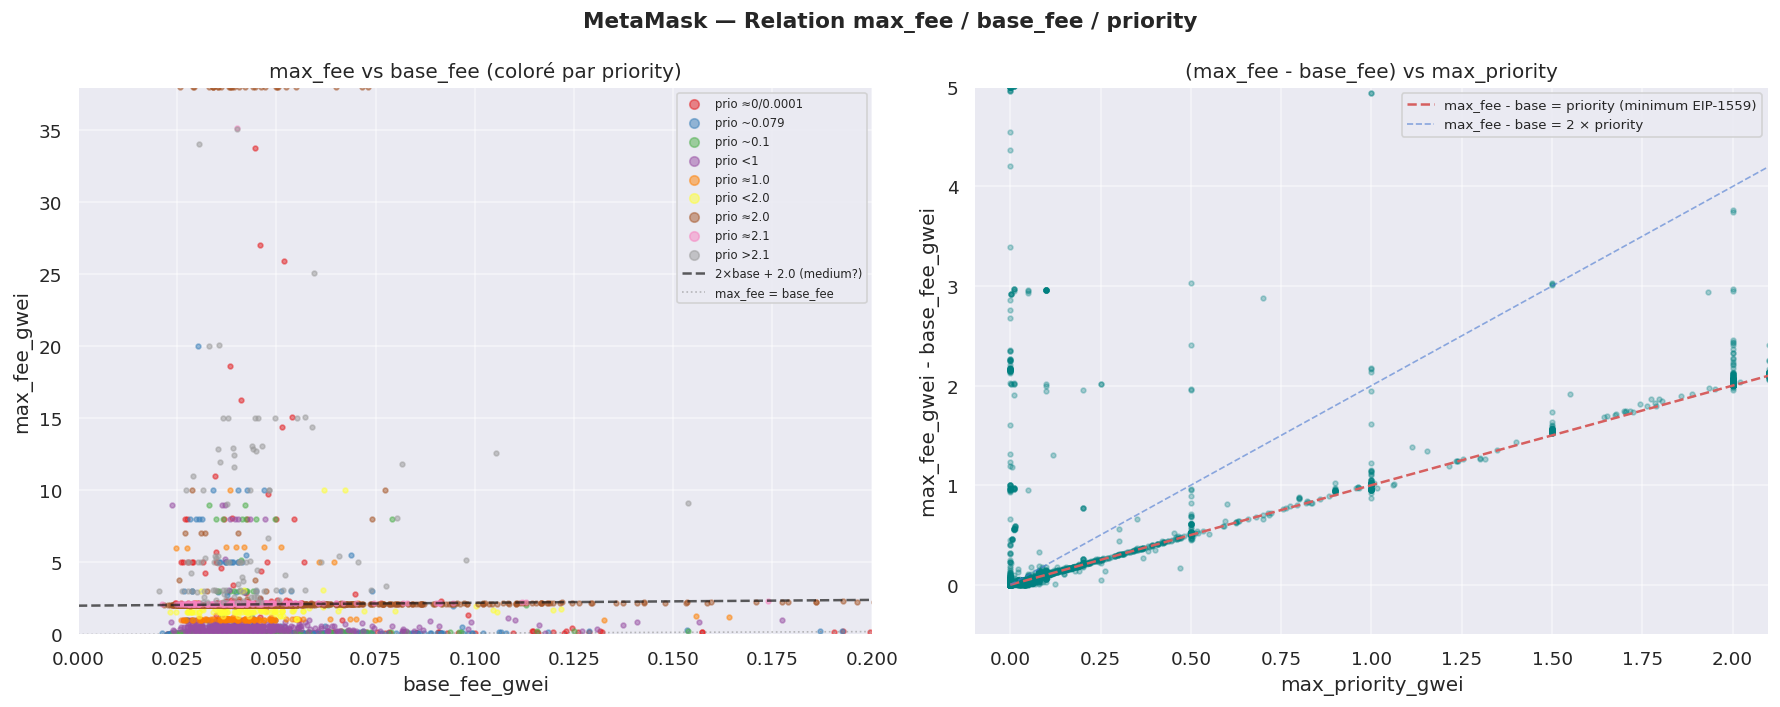

In [24]:
df_scatter = df[
    (df['base_fee_gwei'] > 0) &
    (df['max_fee_gwei'] > 0) &
    (df['max_priority_gwei'].notna())
].copy()

# Segmenter par priority dominante MetaMask
df_scatter['prio_label'] = pd.cut(
    df_scatter['max_priority_gwei'],
    bins=[-0.001, 0.00015, 0.08, 0.12, 0.95, 1.05, 1.95, 2.05, 2.15, 999],
    labels=['≈0/0.0001', '~0.079', '~0.1', '<1', '≈1.0', '<2.0', '≈2.0', '≈2.1', '>2.1']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sample = df_scatter.sample(min(6000, len(df_scatter)), random_state=42)
palette = sns.color_palette('Set1', n_colors=9)
for i, label in enumerate(['≈0/0.0001', '~0.079', '~0.1', '<1', '≈1.0', '<2.0', '≈2.0', '≈2.1', '>2.1']):
    mask = sample['prio_label'] == label
    if mask.sum() > 0:
        axes[0].scatter(sample[mask]['base_fee_gwei'], sample[mask]['max_fee_gwei'],
                        s=8, alpha=0.5, label=f'prio {label}', color=palette[i])

x_range = np.linspace(0, df_scatter['base_fee_gwei'].quantile(0.99), 100)
# Formule EIP-1559 typique MetaMask medium: max_fee = 2 × base_fee + prio
axes[0].plot(x_range, 2 * x_range + 2.0, 'k--', linewidth=1.5, label='2×base + 2.0 (medium?)', alpha=0.7)
axes[0].plot(x_range, x_range, 'gray', linewidth=1, linestyle=':', label='max_fee = base_fee', alpha=0.5)
axes[0].set_xlabel('base_fee_gwei')
axes[0].set_ylabel('max_fee_gwei')
axes[0].set_title('max_fee vs base_fee (coloré par priority)')
axes[0].legend(fontsize=7, markerscale=2)
axes[0].set_xlim(0, df_scatter['base_fee_gwei'].quantile(0.99))
axes[0].set_ylim(0, df_scatter['max_fee_gwei'].quantile(0.99))

# (max_fee - base_fee) vs max_priority → doit être ≥ priority
df_scatter['max_fee_minus_base'] = df_scatter['max_fee_gwei'] - df_scatter['base_fee_gwei']
sample2 = df_scatter.sample(min(6000, len(df_scatter)), random_state=42)
axes[1].scatter(sample2['max_priority_gwei'], sample2['max_fee_minus_base'],
                s=8, alpha=0.3, color='teal')
axes[1].plot([0, 5], [0, 5], 'r--', linewidth=1.5, label='max_fee - base = priority (minimum EIP-1559)')
axes[1].plot([0, 5], [0, 10], 'b--', linewidth=1, alpha=0.6, label='max_fee - base = 2 × priority')
axes[1].set_xlabel('max_priority_gwei')
axes[1].set_ylabel('max_fee_gwei - base_fee_gwei')
axes[1].set_title('(max_fee - base_fee) vs max_priority')
axes[1].set_xlim(-0.1, df_scatter['max_priority_gwei'].quantile(0.97))
axes[1].set_ylim(-0.5, df_scatter['max_fee_minus_base'].quantile(0.97))
axes[1].legend(fontsize=8)

plt.suptitle(f'{WALLET} — Relation max_fee / base_fee / priority', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Vérifier la formule EIP-1559 MetaMask : max_fee = 2 × base_fee + max_priority ?
df_formula = df_scatter[df_scatter['max_priority_gwei'].notna()].copy()
df_formula['predicted_medium'] = 2 * df_formula['base_fee_gwei'] + df_formula['max_priority_gwei']
df_formula['err_medium'] = (df_formula['max_fee_gwei'] - df_formula['predicted_medium']).abs()
df_formula['rel_err_medium'] = df_formula['err_medium'] / df_formula['max_fee_gwei']

threshold = 0.01  # 1% d'erreur relative
match = (df_formula['rel_err_medium'] < threshold).sum()
print(f"Formule max_fee = 2×base_fee + priority : {match:,}/{len(df_formula):,} txs ({match/len(df_formula)*100:.1f}%) avec erreur <1%")

# Restreindre au mode medium (prio=2.0)
medium = df_formula[df_formula['max_priority_gwei'].round(1) == 2.0]
match_medium = (medium['rel_err_medium'] < threshold).sum()
print(f"  → sur les txs prio=2.0 : {match_medium:,}/{len(medium):,} ({match_medium/len(medium)*100:.1f}%) matchent")

Formule max_fee = 2×base_fee + priority : 17,934/99,617 txs (18.0%) avec erreur <1%
  → sur les txs prio=2.0 : 13,634/34,316 (39.7%) matchent


## 7. Heatmap — combinaison (gas_limit_factor × max_priority_gwei)

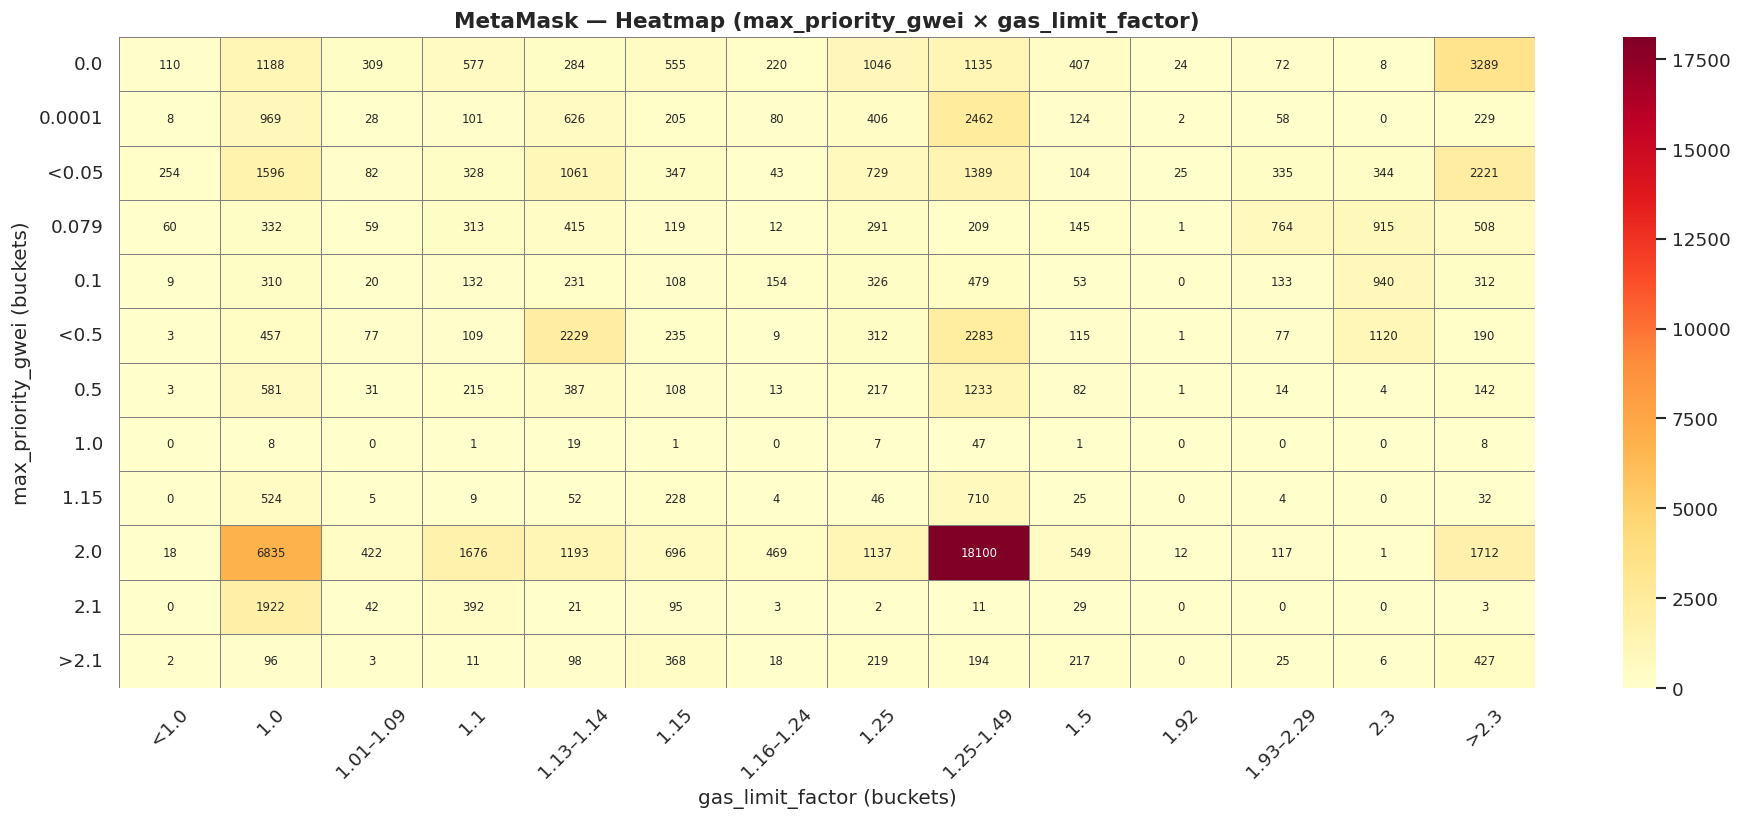

In [26]:
df_heat = df[df['gas_limit_factor'].notna() & df['max_priority_gwei'].notna()].copy()

glf_bins   = [0, 0.99, 1.01, 1.09, 1.13, 1.17, 1.24, 1.26, 1.49, 1.51, 1.92, 1.94, 2.29, 2.31, 100]
glf_labels = ['<1.0', '1.0', '1.01–1.09', '1.1', '1.13–1.14', '1.15', '1.16–1.24', '1.25', '1.25–1.49', '1.5', '1.92', '1.93–2.29', '2.3', '>2.3']

prio_bins   = [-0.001, 0.00005, 0.00015, 0.05, 0.09, 0.11, 0.55, 1.05, 1.15, 1.95, 2.05, 2.15, 999]
prio_labels = ['0.0', '0.0001', '<0.05', '0.079', '0.1', '<0.5', '0.5', '1.0', '1.15', '2.0', '2.1', '>2.1']

df_heat['glf_bin']  = pd.cut(df_heat['gas_limit_factor'], bins=glf_bins,  labels=glf_labels[:len(glf_bins)-1])
df_heat['prio_bin'] = pd.cut(df_heat['max_priority_gwei'], bins=prio_bins, labels=prio_labels[:len(prio_bins)-1])

pivot = df_heat.groupby(['prio_bin', 'glf_bin'], observed=True).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='gray', annot_kws={'size': 7})
ax.set_title(f'{WALLET} — Heatmap (max_priority_gwei × gas_limit_factor)', fontsize=13, fontweight='bold')
ax.set_xlabel('gas_limit_factor (buckets)')
ax.set_ylabel('max_priority_gwei (buckets)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Segmentation des modes — clustering visuel

mode
Autre                              39992
Mode MEDIUM: prio≈2.0, glf=1.5     18278
Mode GLF×1.0 (exact)               15064
Mode SLOW: prio≈0.0001, glf=1.5     3872
Mode GLF×2.3                        3459
Mode GLF×1.92                        233
Mode X: prio≈1.15, glf=1.5            34
Mode FAST: prio≈2.1, glf=1.5          11


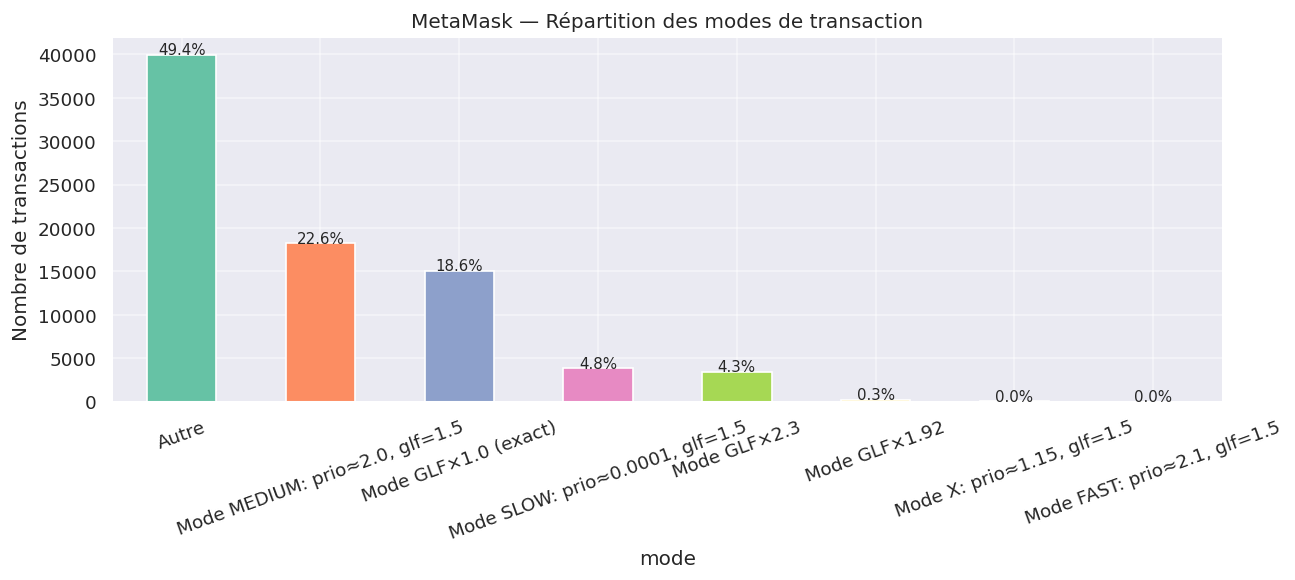

In [27]:
df_modes = df[
    df['gas_limit_factor'].notna() &
    df['max_priority_gwei'].notna() &
    df['fee_factor'].notna()
].copy()

def classify_mode(row):
    prio = row['max_priority_gwei']
    glf  = row['gas_limit_factor']
    ff   = row['fee_factor']
    # Mode medium : prio=2.0 + glf=1.5 + fee_factor dynamique
    if abs(prio - 2.0) < 0.05 and abs(glf - 1.5) < 0.05:
        return 'Mode MEDIUM: prio≈2.0, glf=1.5'
    # Mode slow : prio=0.0001 + glf=1.5
    elif prio <= 0.0002 and abs(glf - 1.5) < 0.05:
        return 'Mode SLOW: prio≈0.0001, glf=1.5'
    # Mode fast : prio=2.1
    elif abs(prio - 2.1) < 0.05 and abs(glf - 1.5) < 0.05:
        return 'Mode FAST: prio≈2.1, glf=1.5'
    # Mode 1.15 (autre vitesse ?)
    elif abs(prio - 1.15) < 0.05 and abs(glf - 1.5) < 0.05:
        return 'Mode X: prio≈1.15, glf=1.5'
    # Gas limit × 2.3
    elif abs(glf - 2.3) < 0.05:
        return 'Mode GLF×2.3'
    # Gas limit × 1.0 (pas de buffer)
    elif abs(glf - 1.0) < 0.02:
        return 'Mode GLF×1.0 (exact)'
    # Gas limit × 1.92
    elif abs(glf - 1.92) < 0.05:
        return 'Mode GLF×1.92'
    else:
        return 'Autre'

df_modes['mode'] = df_modes.apply(classify_mode, axis=1)
mode_counts = df_modes['mode'].value_counts()
print(mode_counts.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
mode_counts.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(mode_counts)), edgecolor='white')
ax.set_title(f'{WALLET} — Répartition des modes de transaction')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=20)
for bar in ax.patches:
    pct = bar.get_height() / len(df_modes) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{pct:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

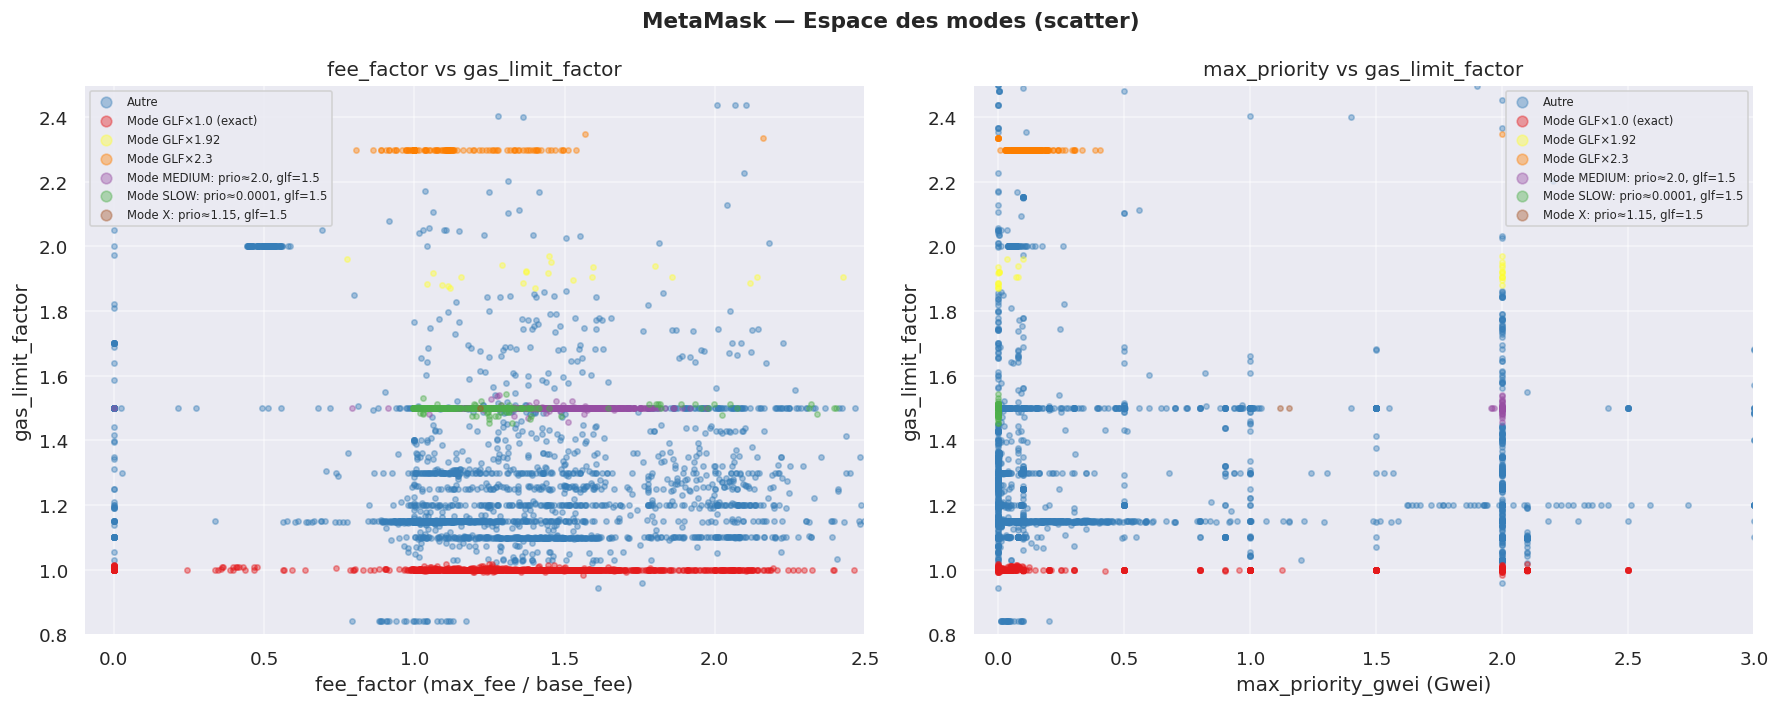

In [28]:
# Scatter 2D coloré par mode
sample_modes = df_modes.sample(min(8000, len(df_modes)), random_state=42)
palette_modes = dict(zip(df_modes['mode'].unique(), sns.color_palette('Set1', df_modes['mode'].nunique())))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for mode, grp in sample_modes.groupby('mode'):
    axes[0].scatter(grp['fee_factor'], grp['gas_limit_factor'],
                    s=10, alpha=0.4, label=mode, color=palette_modes.get(mode, 'gray'))
axes[0].set_xlabel('fee_factor (max_fee / base_fee)')
axes[0].set_ylabel('gas_limit_factor')
axes[0].set_title('fee_factor vs gas_limit_factor')
axes[0].set_xlim(-0.1, 2.5)
axes[0].set_ylim(0.8, 2.5)
axes[0].legend(fontsize=7, markerscale=2)

for mode, grp in sample_modes.groupby('mode'):
    axes[1].scatter(grp['max_priority_gwei'], grp['gas_limit_factor'],
                    s=10, alpha=0.4, label=mode, color=palette_modes.get(mode, 'gray'))
axes[1].set_xlabel('max_priority_gwei (Gwei)')
axes[1].set_ylabel('gas_limit_factor')
axes[1].set_title('max_priority vs gas_limit_factor')
axes[1].set_xlim(-0.1, 3.0)
axes[1].set_ylim(0.8, 2.5)
axes[1].legend(fontsize=7, markerscale=2)

plt.suptitle(f'{WALLET} — Espace des modes (scatter)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Zoom sur le mode MEDIUM — fee_factor en fonction du basefee

Transactions mode MEDIUM : 18,059
  fee_factor médian  : 1.4466
  fee_factor moyen   : 1.9170
  fee_factor std     : 26.5627
  fee_factor min/max : 0.0000 / 2277.7018


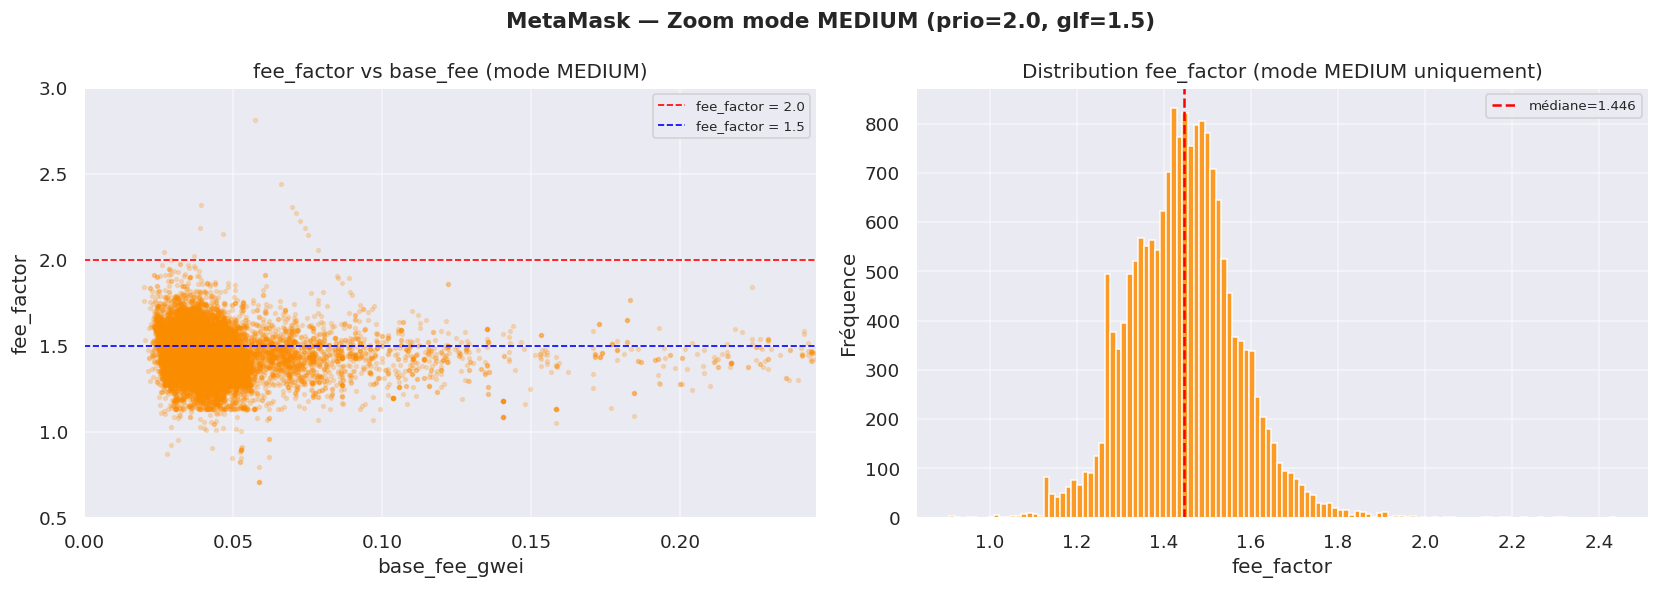

In [29]:
# Le mode medium (prio=2.0, glf=1.5) est le plus massif — analyser son fee_factor
medium = df[
    (df['max_priority_gwei'].round(1) == 2.0) &
    (df['gas_limit_factor'].round(2) == 1.5) &
    df['fee_factor'].notna() &
    (df['base_fee_gwei'] > 0)
].copy()

print(f"Transactions mode MEDIUM : {len(medium):,}")
print(f"  fee_factor médian  : {medium['fee_factor'].median():.4f}")
print(f"  fee_factor moyen   : {medium['fee_factor'].mean():.4f}")
print(f"  fee_factor std     : {medium['fee_factor'].std():.4f}")
print(f"  fee_factor min/max : {medium['fee_factor'].min():.4f} / {medium['fee_factor'].max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# fee_factor vs base_fee
axes[0].scatter(medium['base_fee_gwei'], medium['fee_factor'],
                s=5, alpha=0.2, color='darkorange')
axes[0].set_xlabel('base_fee_gwei')
axes[0].set_ylabel('fee_factor')
axes[0].set_title('fee_factor vs base_fee (mode MEDIUM)')
axes[0].set_xlim(0, medium['base_fee_gwei'].quantile(0.99))
axes[0].set_ylim(0.5, 3.0)
axes[0].axhline(2.0, color='red', linestyle='--', linewidth=1, label='fee_factor = 2.0')
axes[0].axhline(1.5, color='blue', linestyle='--', linewidth=1, label='fee_factor = 1.5')
axes[0].legend(fontsize=8)

# Distribution du fee_factor mode medium
zoom_ff = medium[(medium['fee_factor'] > 0.9) & (medium['fee_factor'] <= 2.5)]
axes[1].hist(zoom_ff['fee_factor'], bins=120, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution fee_factor (mode MEDIUM uniquement)')
axes[1].set_xlabel('fee_factor')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(zoom_ff['fee_factor'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f'médiane={zoom_ff["fee_factor"].median():.3f}')
axes[1].legend(fontsize=8)

plt.suptitle(f'{WALLET} — Zoom mode MEDIUM (prio=2.0, glf=1.5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Évolution temporelle — patterns par block

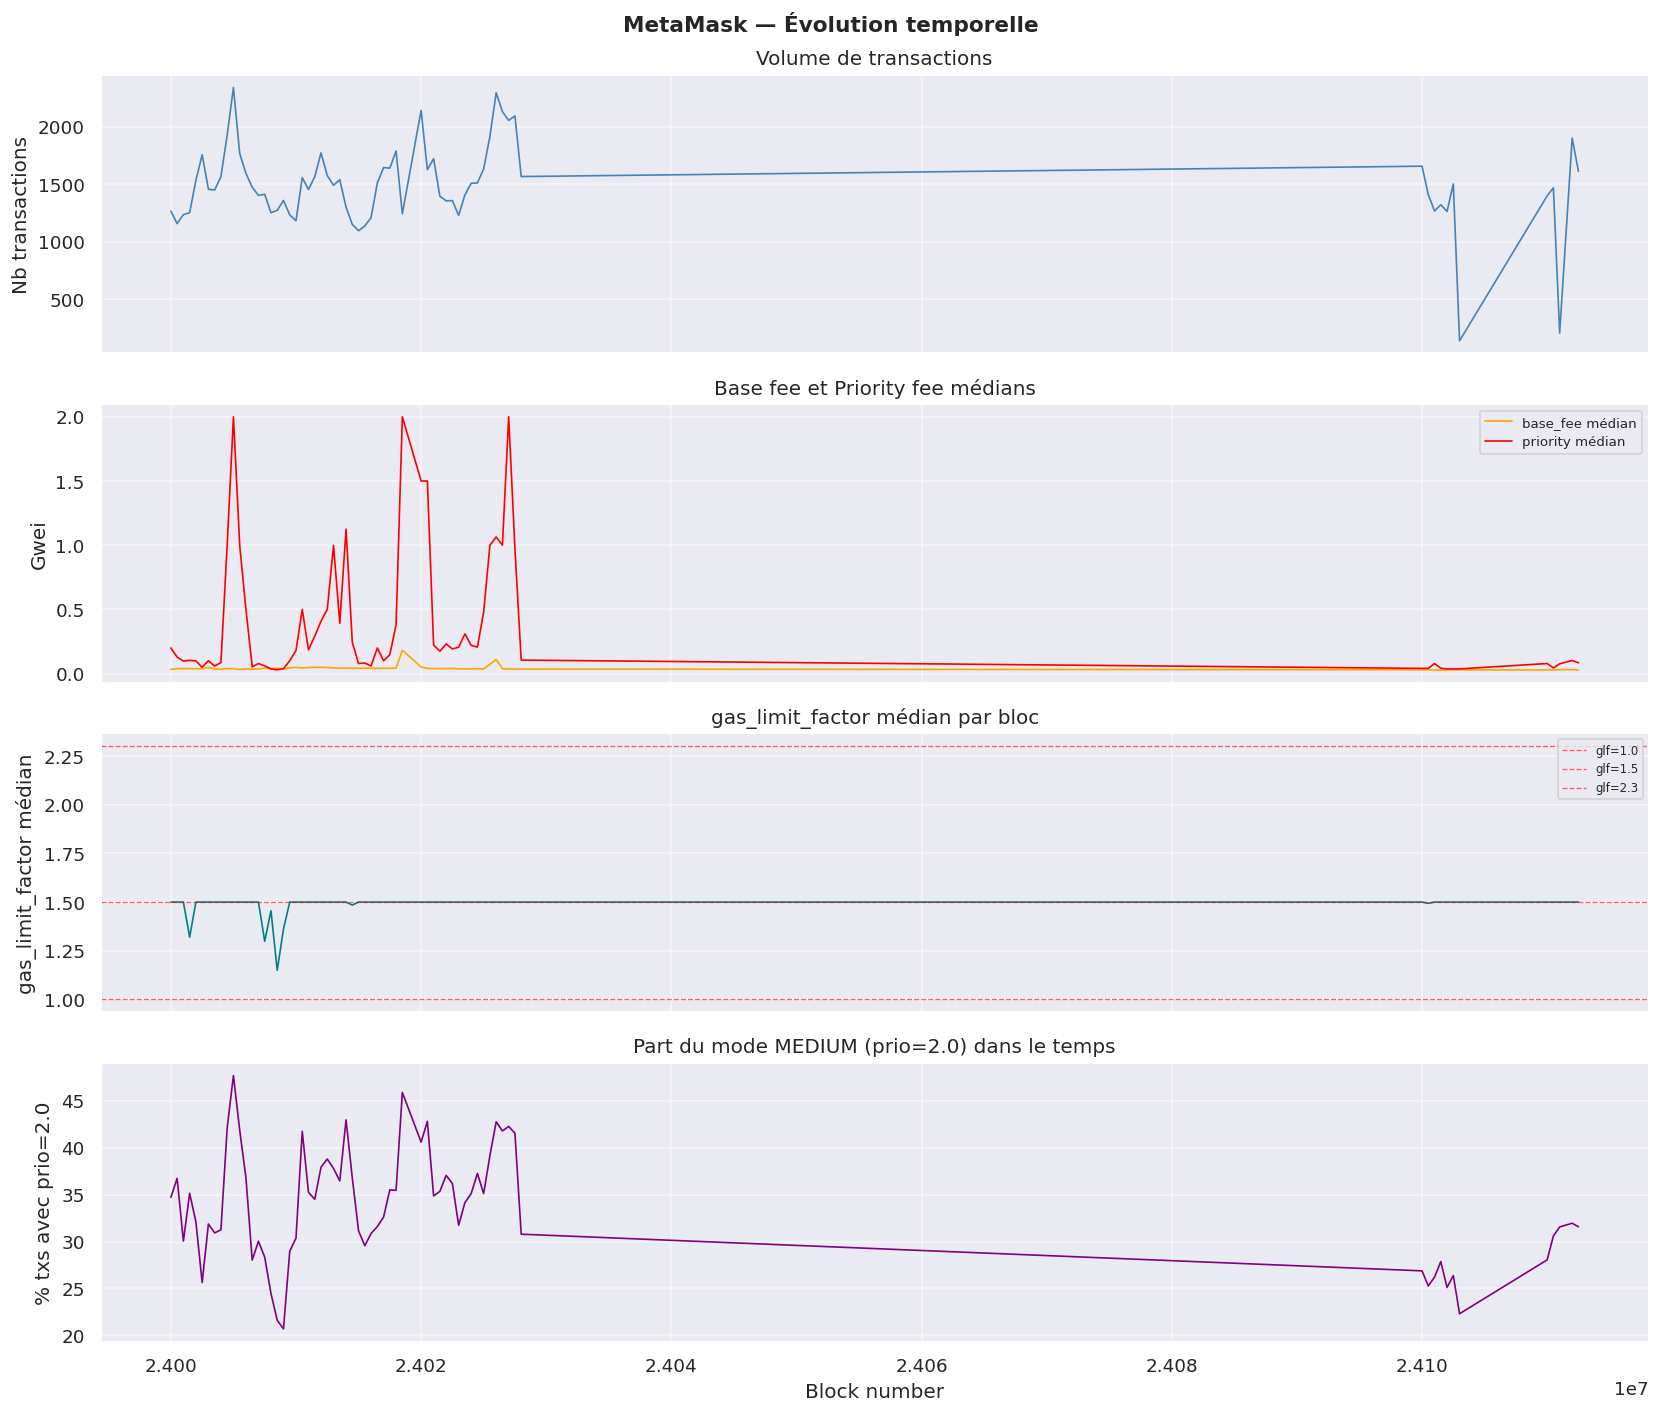

In [30]:
df_time = df[df['max_priority_gwei'].notna()].copy()
block_step = 500
df_time['block_bucket'] = (df_time['block'] // block_step) * block_step

block_stats = df_time.groupby('block_bucket').agg(
    n_txs=('hash', 'count'),
    avg_prio=('max_priority_gwei', 'median'),
    avg_basefee=('base_fee_gwei', 'median'),
    avg_glf=('gas_limit_factor', 'median'),
    pct_prio2=('max_priority_gwei', lambda x: (x.round(1)==2.0).mean()*100)
).reset_index()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(block_stats['block_bucket'], block_stats['n_txs'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Nb transactions')
axes[0].set_title('Volume de transactions')

axes[1].plot(block_stats['block_bucket'], block_stats['avg_basefee'], color='orange', linewidth=1, label='base_fee médian')
axes[1].plot(block_stats['block_bucket'], block_stats['avg_prio'], color='red', linewidth=1, label='priority médian')
axes[1].set_ylabel('Gwei')
axes[1].set_title('Base fee et Priority fee médians')
axes[1].legend(fontsize=8)

axes[2].plot(block_stats['block_bucket'], block_stats['avg_glf'], color='teal', linewidth=1)
for v in [1.0, 1.5, 2.3]:
    axes[2].axhline(v, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label=f'glf={v}')
axes[2].set_ylabel('gas_limit_factor médian')
axes[2].set_title('gas_limit_factor médian par bloc')
axes[2].legend(fontsize=7)

axes[3].plot(block_stats['block_bucket'], block_stats['pct_prio2'], color='purple', linewidth=1)
axes[3].set_ylabel('% txs avec prio=2.0')
axes[3].set_title('Part du mode MEDIUM (prio=2.0) dans le temps')
axes[3].set_xlabel('Block number')

plt.suptitle(f'{WALLET} — Évolution temporelle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Synthèse — signature fingerprint MetaMask

In [31]:
print("=" * 60)
print(f"  SYNTHÈSE FINGERPRINT — {WALLET}")
print("=" * 60)

total = len(df)
print(f"\nTotal transactions analysées : {total:,}")

# gas_limit_factor
print(f"\n[gas_limit_factor]")
for v, lbl in [(1.5, '1.5'), (1.0, '1.0'), (1.15, '1.15'), (1.1, '1.1'), (2.3, '2.3'), (1.92, '1.92')]:
    n = (df['gas_limit_factor'].round(2) == v).sum()
    print(f"  × {lbl:<5} → {n:>6,} txs ({n/total*100:.1f}%)")
n_null = df['gas_limit_factor'].isna().sum()
print(f"  NULL   → {n_null:>6,} txs ({n_null/total*100:.1f}%) ← gasLimit hardcodé")

# max_priority_gwei
df_p = df[df['max_priority_gwei'].notna()]
print(f"\n[max_priority_gwei]")
for v, lbl in [(2.0, '2.0 (MEDIUM)'), (0.0001, '0.0001 (SLOW?)'), (2.1, '2.1 (FAST?)'),
               (1.15, '1.15'), (0.5, '0.5'), (1.0, '1.0')]:
    n = (df_p['max_priority_gwei'].round(4) == v).sum()
    print(f"  {lbl:<20} → {n:>6,} txs ({n/len(df_p)*100:.1f}%)")
n0 = (df_p['max_priority_gwei'] == 0.0).sum()
print(f"  0.0                  → {n0:>6,} txs ({n0/len(df_p)*100:.1f}%)")

# fee_factor
df_f = df[df['fee_factor'].notna()]
ff0 = (df_f['fee_factor'] == 0.0).sum()
ff1 = ((df_f['fee_factor'] > 0.99) & (df_f['fee_factor'] < 1.01)).sum()
print(f"\n[fee_factor]")
print(f"  0.0  → {ff0:>6,} txs ({ff0/total*100:.1f}%)")
print(f"  ≈1.0 → {ff1:>6,} txs ({ff1/total*100:.1f}%)")
dynamic = df_f[(df_f['fee_factor'] > 1.01)]
print(f"  >1.0 (dynamique) → {len(dynamic):>6,} txs ({len(dynamic)/total*100:.1f}%)")
print(f"    médiane : {dynamic['fee_factor'].median():.4f}")

# Pattern dominant
main = df[
    (df['max_priority_gwei'].round(1) == 2.0) &
    (df['gas_limit_factor'].round(2) == 1.5)
]
print(f"\n[Pattern dominant] prio=2.0 + glf=1.5 → {len(main):,} txs ({len(main)/total*100:.1f}%)")
print()
print("=" * 60)

  SYNTHÈSE FINGERPRINT — MetaMask

Total transactions analysées : 102,432

[gas_limit_factor]
  × 1.5   → 28,342 txs (27.7%)
  × 1.0   → 15,789 txs (15.4%)
  × 1.15  →  5,959 txs (5.8%)
  × 1.1   →  3,534 txs (3.5%)
  × 2.3   →  3,325 txs (3.2%)
  × 1.92  →    425 txs (0.4%)
  NULL   → 18,746 txs (18.3%) ← gasLimit hardcodé

[max_priority_gwei]
  2.0 (MEDIUM)         → 34,242 txs (34.4%)
  0.0001 (SLOW?)       →  5,714 txs (5.7%)
  2.1 (FAST?)          →  2,980 txs (3.0%)
  1.15                 →      0 txs (0.0%)
  0.5                  →  2,015 txs (2.0%)
  1.0                  →  1,960 txs (2.0%)
  0.0                  →  9,955 txs (10.0%)

[fee_factor]
  0.0  →  3,008 txs (2.9%)
  ≈1.0 → 14,164 txs (13.8%)
  >1.0 (dynamique) → 76,048 txs (74.2%)
    médiane : 1.4043

[Pattern dominant] prio=2.0 + glf=1.5 → 18,059 txs (17.6%)

